# 06 — Interpretação dos Clusters (K-Means, K=5)

Este notebook analisa e interpreta os 5 clusters gerados pelo notebook `05-Kmeans.ipynb`,
cruzando os perfis de qualidade de telecomunicações (RQUAL) com os dados socioeconômicos e geográficos do IBGE.

**Entrada:** `rqual_2022_clusterizado.parquet`  
**Saída:** tabelas, gráficos e narrativa interpretativa por cluster

---

## Resumo dos clusters encontrados

| Cluster | N municípios | Perfil resumido |
|---------|-------------|------------------|
| **0** | 216 | Urbano-avançado: alta banda, alto PIB per capita, IDHM elevado (Sul/Sudeste) |
| **1** | 3.054 | Intermediário: desempenho médio em todos os indicadores (Sul/Sudeste) |
| **2** | 2.057 | Nordeste periférico: baixa resolução de problemas, maior população rural |
| **3** | 216 | Norte/Amazônico: pior atendimento e solução, municípios extensos e remotos |
| **4** | 27 | Capitais/destaques: um por UF, densidade e upload excepcionais |

In [1]:
# Bloco 0 — Setup e carregamento
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Carregar base clusterizada
ARQ = Path('rqual_2022_clusterizado.parquet')
df = pd.read_parquet(ARQ)

print(f'Shape: {df.shape}')
print(f'Clusters K-Means: {sorted(df["kmeans_cluster"].unique())}')
print(f'Distribuição:')
display(df['kmeans_cluster'].value_counts().sort_index().rename('n_municípios'))

Shape: (5570, 26)
Clusters K-Means: [0, 1, 2, 3, 4]
Distribuição:


kmeans_cluster
0     216
1    3054
2    2057
3     216
4      27
Name: n_municípios, dtype: int64

In [2]:
# Bloco 1 — Padronizar nomes de colunas para análise

# Indicadores RQUAL
IND_COLS = [c for c in ['IND2','IND4','IND5','IND8','IND9','INF1','INF4-UP'] if c in df.columns]

# Renomear colunas socioeconômicas para nomes curtos
rename_map = {}
for col in df.columns:
    if 'Agropecuária' in col or 'Agropecuaria' in col:
        rename_map[col] = 'pib_agropecuaria'
    elif 'Indústria' in col or 'Industria' in col:
        rename_map[col] = 'pib_industria'
    elif 'per capita' in col.lower() or 'Per capita' in col:
        rename_map[col] = 'pib_per_capita'
    elif 'Área' in col or 'Area' in col:
        rename_map[col] = 'area_km2'
    elif 'Densidade' in col or 'densidade' in col:
        rename_map[col] = 'densidade'
    elif 'Rural' in col and 'URB' in col:
        rename_map[col] = 'pop_rural'
    elif 'IDHM' in col:
        rename_map[col] = 'idhm'
    elif col.startswith('LAT__lat'):
        rename_map[col] = 'lat'
    elif col.startswith('LAT__lon'):
        rename_map[col] = 'lon'

df = df.rename(columns=rename_map)

SOC_COLS = [c for c in ['pib_agropecuaria','pib_industria','pib_per_capita',
                         'area_km2','densidade','pop_rural','idhm'] if c in df.columns]

print('Indicadores RQUAL:', IND_COLS)
print('Socioeconômicas:', SOC_COLS)

Indicadores RQUAL: ['IND2', 'IND4', 'IND5', 'IND8', 'IND9', 'INF1', 'INF4-UP']
Socioeconômicas: ['pib_agropecuaria', 'pib_industria', 'pib_per_capita', 'area_km2', 'densidade', 'pop_rural', 'idhm']


## 1. Perfil médio por cluster (z-scores)

In [3]:
# Bloco 2 — Tabela de perfil médio (valores já em z-score do pipeline anterior)

CLUSTER_LABELS = {
    0: 'C0: Urbano-Avançado (216)',
    1: 'C1: Intermediário (3.054)',
    2: 'C2: Nordeste Periférico (2.057)',
    3: 'C3: Norte/Amazônico (216)',
    4: 'C4: Capitais/Destaques (27)',
}

todas_feats = IND_COLS + SOC_COLS
perfil = df.groupby('kmeans_cluster')[todas_feats].mean().round(3)
perfil.index = perfil.index.map(CLUSTER_LABELS)

print('Perfil médio por cluster (z-scores):')
display(perfil)

Perfil médio por cluster (z-scores):


,IND2,IND4,IND5,IND8,IND9,INF1,INF4-UP,pib_agropecuaria,pib_industria,pib_per_capita,area_km2,densidade,pop_rural,idhm
kmeans_cluster,,,,,,,,,,,,,,
C0: Urbano-Avançado (216),-0.512,-0.149,0.540,0.165,0.544,-0.531,1.242,-0.007,1.464,1.108,-0.150,1.400,0.019,1.264
C1: Intermediário (3.054),-0.045,0.185,0.285,0.129,0.010,-0.099,-0.037,0.042,-0.098,0.158,-0.135,-0.114,-0.344,0.593
C2: Nordeste Periférico (2.057),0.069,-0.055,-0.264,-0.078,-0.069,0.176,-0.096,-0.242,-0.142,-0.440,-0.108,-0.109,0.331,-0.938
C3: Norte/Amazônico (216),0.166,-1.702,-2.086,-0.652,-0.072,0.330,-0.310,0.789,-0.100,0.093,1.886,-0.189,1.124,-0.917
C4: Capitais/Destaques (27),-0.680,0.140,0.283,0.069,0.360,-0.569,1.380,0.380,1.990,0.149,0.277,2.063,0.906,1.629


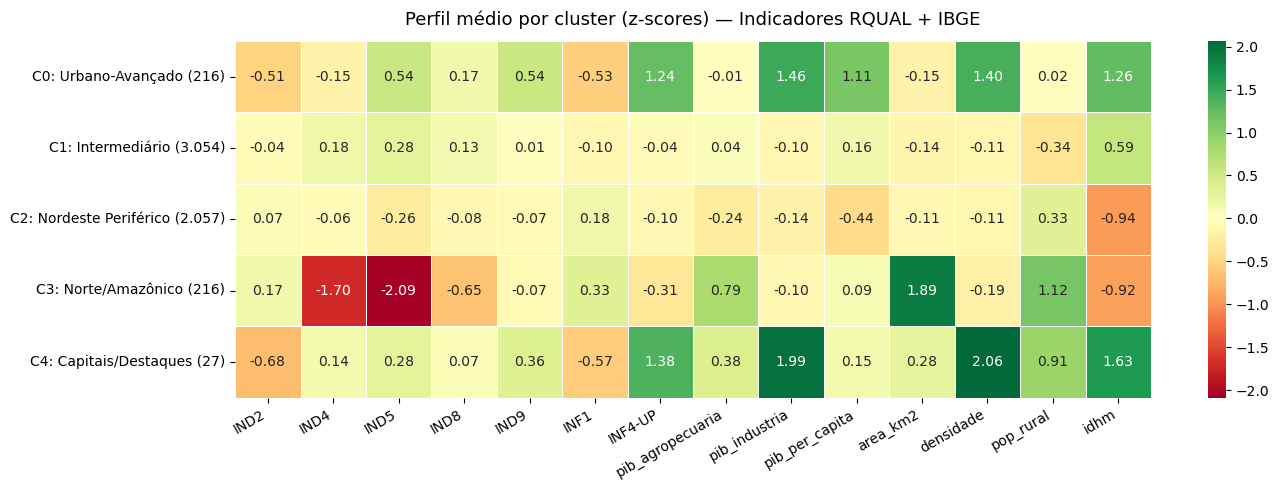

Salvo: fig_perfil_clusters_heatmap.png


In [4]:
# Bloco 3 — Heatmap de perfil dos clusters

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    perfil[todas_feats],
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Perfil médio por cluster (z-scores) — Indicadores RQUAL + IBGE', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_perfil_clusters_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_perfil_clusters_heatmap.png')

## 2. Distribuição geográfica por cluster

In [5]:
# Bloco 4 — Distribuição por UF e região

# Mapa região por UF
UF_REGIAO = {
    'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste',
    'PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul',
}

df['regiao'] = df['uf_rqual'].map(UF_REGIAO)

regiao_dist = (
    df.groupby(['kmeans_cluster','regiao'])
    .size()
    .unstack(fill_value=0)
    .assign(Total=lambda d: d.sum(axis=1))
)

# Percentual por cluster
regiao_pct = regiao_dist.div(regiao_dist['Total'], axis=0).drop(columns='Total').mul(100).round(1)
regiao_pct.index = regiao_pct.index.map(CLUSTER_LABELS)

print('Distribuição regional por cluster (%):')
display(regiao_pct)

Distribuição regional por cluster (%):


regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
kmeans_cluster,,,,,
C0: Urbano-Avançado (216),3.2,8.8,2.3,66.7,19.0
C1: Intermediário (3.054),13.6,0.2,1.1,47.5,37.5
C2: Nordeste Periférico (2.057),0.0,84.2,12.5,3.3,0.0
C3: Norte/Amazônico (216),18.1,13.0,68.1,0.9,0.0
C4: Capitais/Destaques (27),14.8,33.3,25.9,14.8,11.1


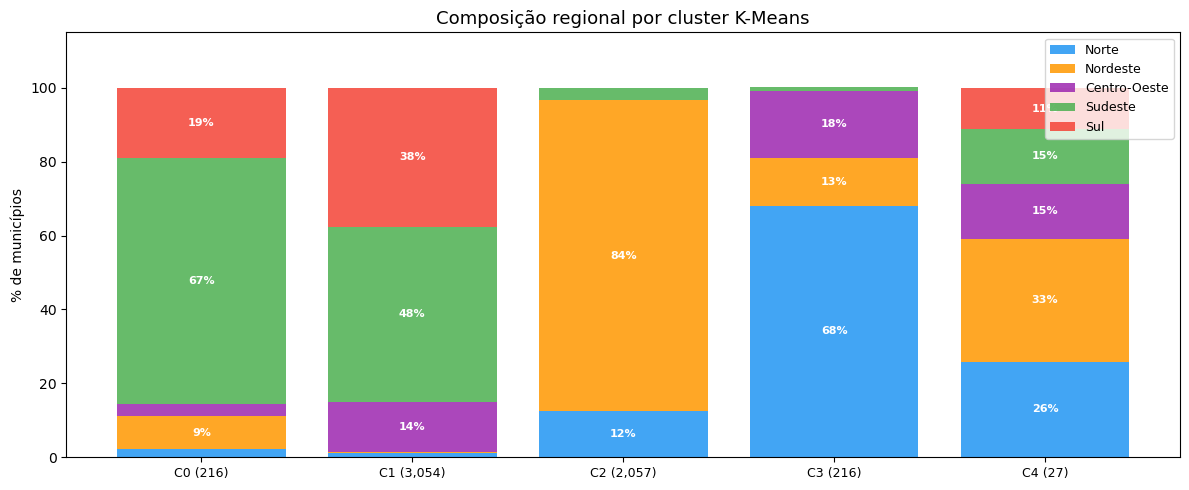

Salvo: fig_distribuicao_regional.png


In [6]:
# Bloco 5 — Gráfico de barras empilhadas por região

cores_regiao = {
    'Norte': '#2196F3',
    'Nordeste': '#FF9800',
    'Centro-Oeste': '#9C27B0',
    'Sudeste': '#4CAF50',
    'Sul': '#F44336',
}

fig, ax = plt.subplots(figsize=(12, 5))

bottom = np.zeros(len(regiao_pct))
for regiao in ['Norte','Nordeste','Centro-Oeste','Sudeste','Sul']:
    if regiao in regiao_pct.columns:
        vals = regiao_pct[regiao].values
        bars = ax.bar(range(len(regiao_pct)), vals, bottom=bottom,
                      label=regiao, color=cores_regiao[regiao], alpha=0.85)
        # rótulo dentro da barra se > 8%
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v > 8:
                ax.text(j, b + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bottom += vals

ax.set_xticks(range(len(regiao_pct)))
ax.set_xticklabels(
    [f'C{i} ({list(df.groupby("kmeans_cluster").size().sort_index())[i]:,})'
     for i in range(len(regiao_pct))],
    fontsize=9
)
ax.set_ylabel('% de municípios')
ax.set_title('Composição regional por cluster K-Means', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 115)
plt.tight_layout()
plt.savefig('fig_distribuicao_regional.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_distribuicao_regional.png')

## 3. Radar chart — comparação dos clusters nos indicadores RQUAL

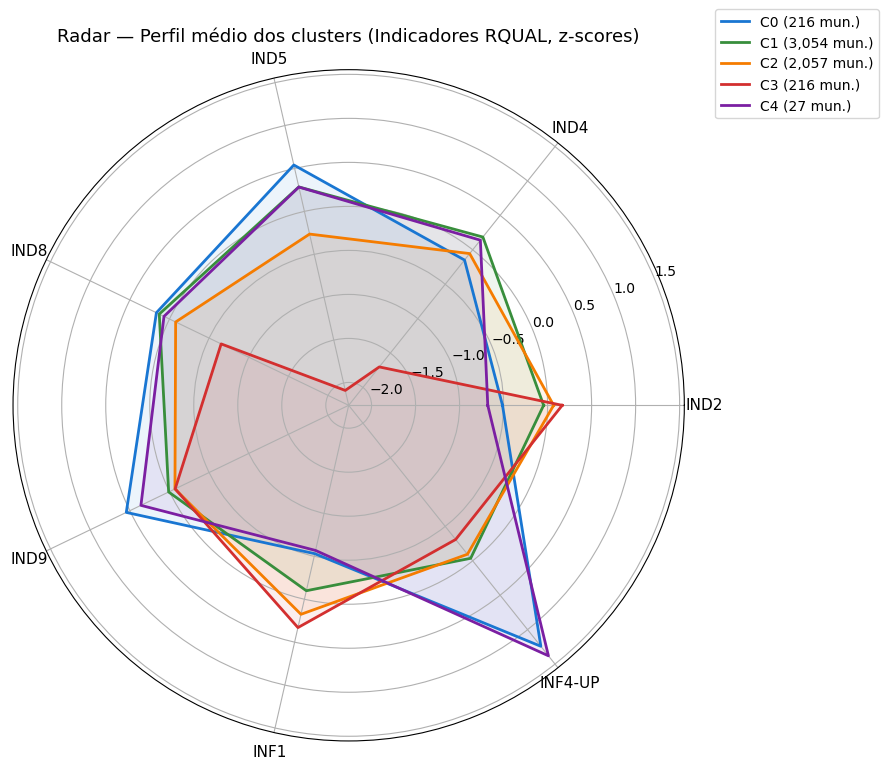

Salvo: fig_radar_clusters.png


In [7]:
# Bloco 6 — Radar chart

from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categorias = IND_COLS
N = len(categorias)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]  # fechar o radar

CORES = ['#1976D2','#388E3C','#F57C00','#D32F2F','#7B1FA2']

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for cluster_id, cor in enumerate(CORES):
    sub = df[df['kmeans_cluster'] == cluster_id]
    valores = sub[categorias].mean().tolist()
    valores += valores[:1]
    label = f'C{cluster_id} ({len(sub):,} mun.)'
    ax.plot(angulos, valores, color=cor, linewidth=2, label=label)
    ax.fill(angulos, valores, color=cor, alpha=0.08)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=11)
ax.set_title('Radar — Perfil médio dos clusters (Indicadores RQUAL, z-scores)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('fig_radar_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_radar_clusters.png')

## 4. Mapa geográfico dos clusters

Municípios sem coordenadas: 0


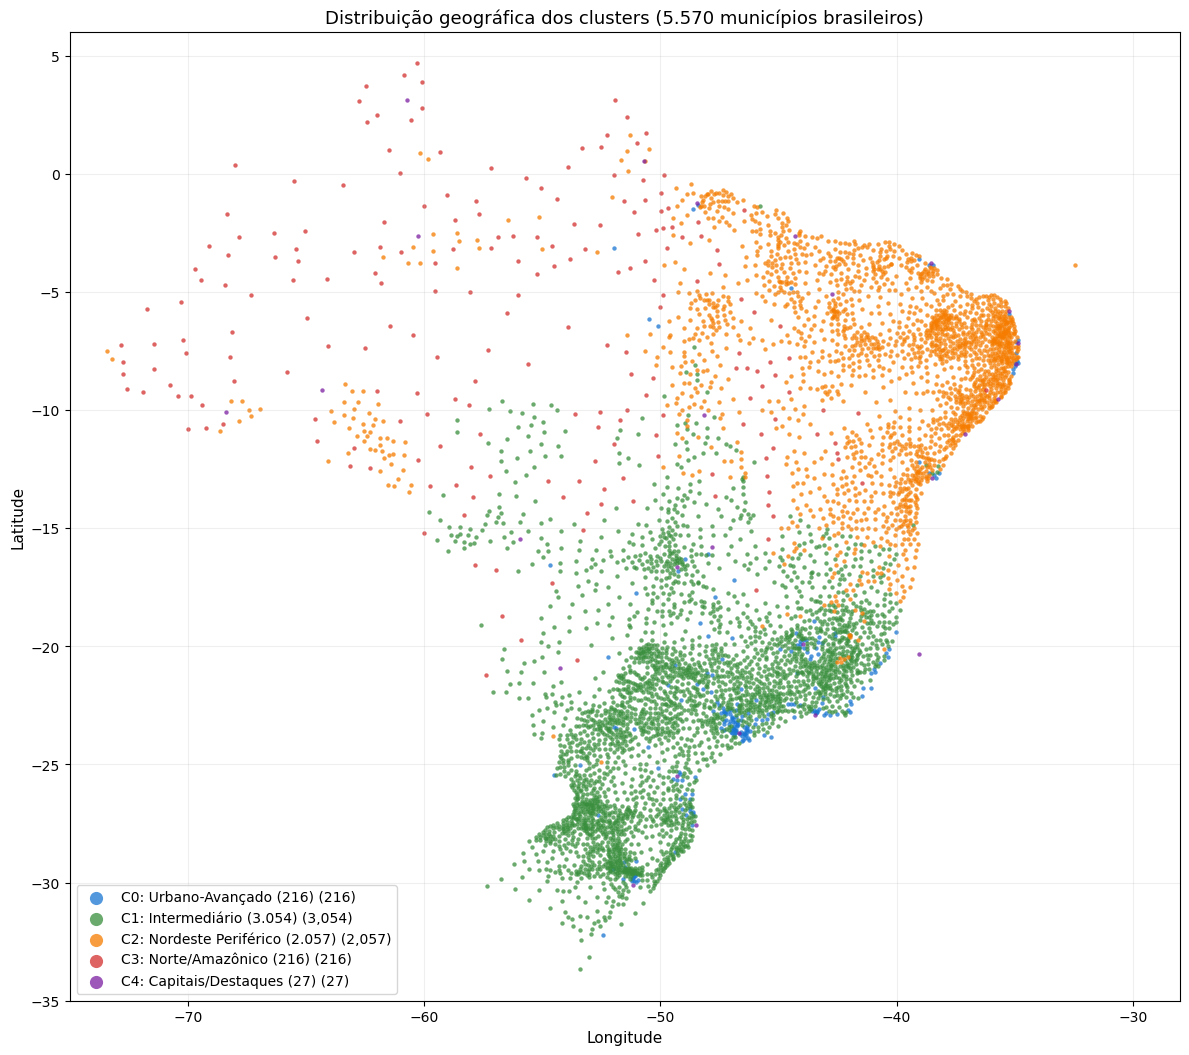

Salvo: fig_mapa_clusters.png


In [8]:
# Bloco 7 — Mapa geográfico dos clusters (coordenadas reais via geobr)

import warnings
warnings.filterwarnings('ignore')

from geobr import read_municipality
import geopandas as gpd

# Obter centroides oficiais de todos os 5.570 municípios
gdf = read_municipality(code_muni='all', year=2020)
gdf = gdf[['code_muni', 'geometry']].copy()

# Reprojetar para CRS projetado antes de calcular centroide (evita distorção)
gdf_proj = gdf.to_crs('EPSG:5880')  # SIRGAS 2000 / Brazil Polyconic
gdf['lat'] = gdf_proj.geometry.centroid.to_crs('EPSG:4326').y
gdf['lon'] = gdf_proj.geometry.centroid.to_crs('EPSG:4326').x
gdf = gdf.rename(columns={'code_muni': 'cod_mun'}).drop(columns='geometry')
gdf['cod_mun'] = gdf['cod_mun'].astype(int)

# Join com base clusterizada
df_map = df[['cod_mun', 'kmeans_cluster']].merge(gdf, on='cod_mun', how='left')
n_sem_coord = df_map[['lat','lon']].isna().any(axis=1).sum()
print(f'Municípios sem coordenadas: {n_sem_coord}')

fig, ax = plt.subplots(figsize=(12, 14))

for cluster_id, cor in enumerate(CORES):
    sub = df_map[df_map['kmeans_cluster'] == cluster_id].dropna(subset=['lat','lon'])
    nome = CLUSTER_LABELS[cluster_id].split(':')[1].strip()
    ax.scatter(
        sub['lon'], sub['lat'],
        c=cor, s=10, alpha=0.75, linewidths=0,
        label=f'C{cluster_id}: {nome} ({len(sub):,})'
    )

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title('Distribuição geográfica dos clusters (5.570 municípios brasileiros)', fontsize=13)
ax.legend(fontsize=10, markerscale=3, loc='lower left')
ax.set_xlim(-75, -28)
ax.set_ylim(-35, 6)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('fig_mapa_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_mapa_clusters.png')

## 5. Análise interpretativa narrativa

### Cluster 0 — Urbano-Avançado (216 municípios)

**Localização:** Concentrado no Sul e Sudeste — São Paulo (81), Minas Gerais (30), Rio de Janeiro (25), Rio Grande do Sul (15), Paraná (13), Santa Catarina (13).

**Perfil de qualidade:**
- `INF4-UP` elevado (+1.24σ): throughput de upload acima da média — serviços de banda larga de maior capacidade
- `IND5` positivo (+0.54σ): alta taxa de resolução de problemas no prazo
- `IND2` negativo (−0.51σ): menos reclamações — usuários mais satisfeitos
- `INF1` negativo (−0.53σ): menor cobertura bruta, mas alta qualidade onde existe

**Perfil socioeconômico:**
- PIB per capita (+1.11σ) e IDHM (+1.26σ) muito acima da média
- Densidade demográfica elevada (+1.40σ)
- Municípios tipicamente metropolitanos ou de grande porte

**Interpretação:** Municípios com maior desenvolvimento socioeconômico e melhor infraestrutura de telecom. A qualidade do serviço acompanha o nível de renda e urbanização.

---

### Cluster 1 — Intermediário (3.054 municípios — 54,8% do total)

**Localização:** Majoritariamente Sul e Sudeste — São Paulo (563), Minas Gerais (754), Rio Grande do Sul (481), Paraná (384), Santa Catarina (281), Goiás (239).

**Perfil de qualidade:**
- Todos os indicadores próximos de zero — desempenho médio nacional
- `IND4` levemente positivo (+0.19σ): atendimento acima da média

**Perfil socioeconômico:**
- PIB per capita (+0.16σ) e IDHM (+0.59σ) acima da média
- Perfil de municípios de médio porte com serviços consolidados

**Interpretação:** Cluster da "maioria silenciosa" — municípios com serviços adequados, sem problemas críticos. Representa o padrão de referência para políticas públicas de manutenção de qualidade.

---

### Cluster 2 — Nordeste Periférico (2.057 municípios — 36,9%)

**Localização:** Nordeste quase exclusivo — Bahia (391), Piauí (217), Paraíba (220), Ceará (180), Pernambuco (177), Maranhão (207), Alagoas (100), Rio Grande do Norte (165), Sergipe (74). Também inclui Pará (86) e Tocantins (98).

**Perfil de qualidade:**
- `IND5` negativo (−0.26σ): baixa taxa de resolução de problemas no prazo — operadoras demoram mais para resolver reclamações
- `IND4` negativo (−0.06σ): ligeiramente menor taxa de atendimento
- `INF1` positivo (+0.18σ): maior cobertura/infraestrutura (paradoxalmente)

**Perfil socioeconômico:**
- PIB per capita (−0.44σ) e IDHM (−0.94σ) bem abaixo da média
- Alta proporção de população rural (+0.33σ)

**Interpretação:** Municípios com infraestrutura expandida (cobertura existe), mas com problemas de **qualidade operacional** — a rede chega, mas o atendimento ao cliente é mais lento. Reflete desafio típico de expansão sem maturidade operacional.

---

### Cluster 3 — Norte/Amazônico (216 municípios)

**Localização:** Amazônia e Norte — Pará (52), Amazonas (50), Mato Grosso (34), Acre (12), Roraima (12), Rondônia (7), Amapá (8), Tocantins (6), Maranhão (7), Bahia (14).

**Perfil de qualidade:**
- `IND5` muito negativo (−2.09σ): **pior resolução de problemas no prazo de todo o Brasil**
- `IND4` muito negativo (−1.70σ): taxa de atendimento crítica
- `IND8` negativo (−0.65σ): menor disponibilidade do serviço

**Perfil socioeconômico:**
- Área territorial muito elevada (+1.89σ) — municípios imensamente extensos
- Alta proporção de população rural (+1.12σ)
- IDHM baixo (−0.92σ)
- Alto VAB agropecuário (+0.79σ) — economia baseada no setor primário

**Interpretação:** Municípios de **alta vulnerabilidade** de telecomunicações. A combinação de área geográfica extensa, baixa densidade e economia primária cria barreiras severas à qualidade de serviço. Prioridade máxima para políticas de expansão e qualidade regulatória.

---

### Cluster 4 — Capitais/Destaques (27 municípios)

**Localização:** Exatamente 1 município por UF (26 UFs + DF = 27) — provavelmente as capitais estaduais.

**Perfil de qualidade:**
- `INF4-UP` muito elevado (+1.38σ): maior throughput de upload do Brasil
- `IND2` negativo (−0.68σ): pouquíssimas reclamações
- `INF1` negativo (−0.57σ): menor cobertura bruta (faz sentido: capitais têm menos município mas altíssima qualidade pontual)

**Perfil socioeconômico:**
- PIB indústria (+1.99σ) e densidade (+2.06σ) excepcionalmente elevados
- IDHM (+1.63σ) mais alto de todos os clusters

**Interpretação:** Capitais ou municípios-polo com infraestrutura premium. Servem como **referência de benchmark** para o que é tecnicamente possível no país quando há investimento e densidade econômica suficientes.

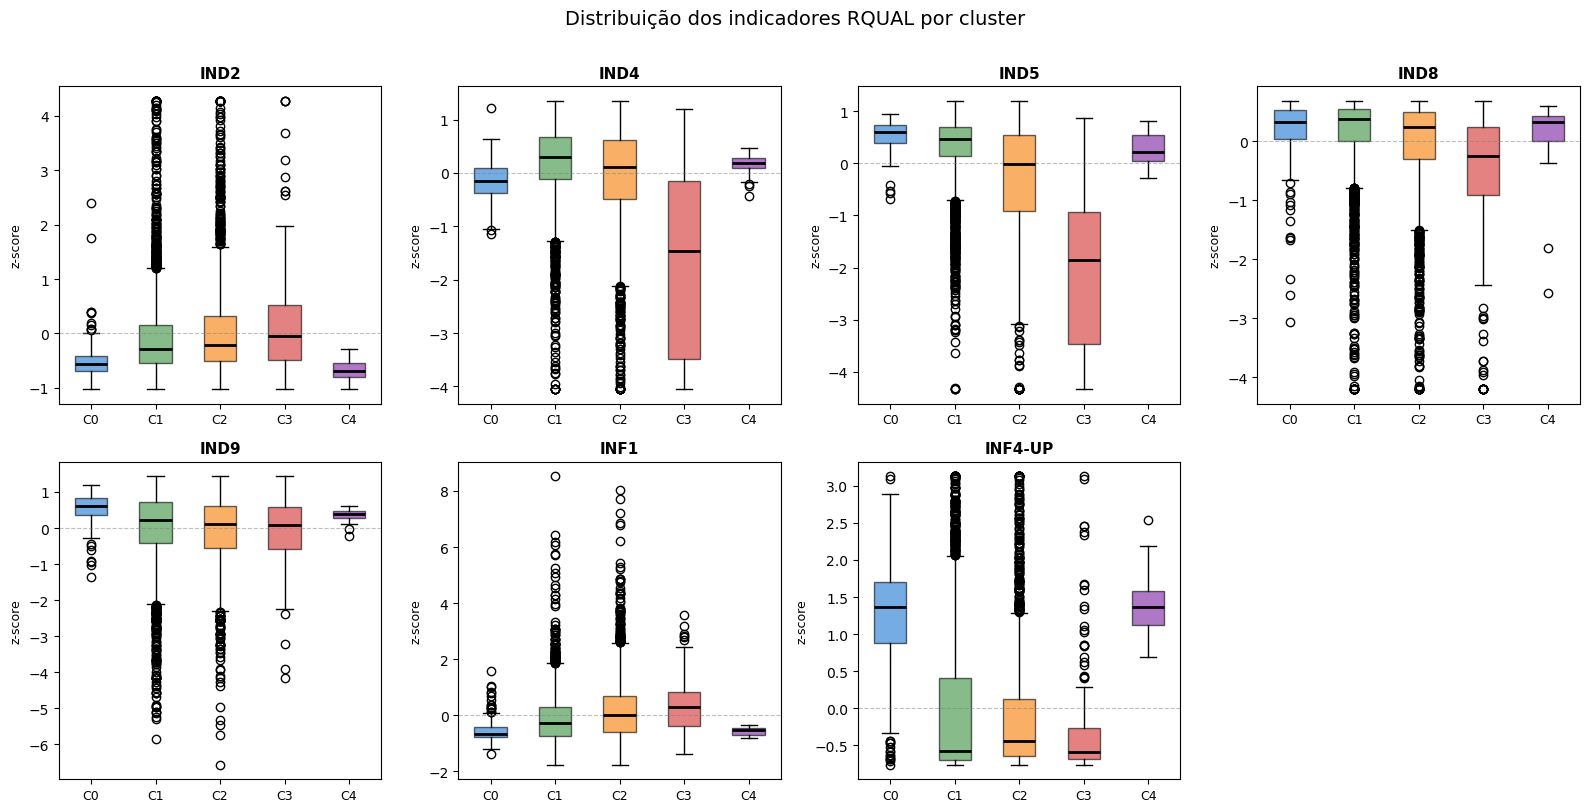

Salvo: fig_boxplot_indicadores.png


In [9]:
# Bloco 8 — Box plots comparativos dos indicadores RQUAL por cluster

n_ind = len(IND_COLS)
ncols = 4
nrows = (n_ind + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, ind in enumerate(IND_COLS):
    ax = axes[i]
    data_by_cluster = [
        df[df['kmeans_cluster'] == c][ind].dropna().values
        for c in sorted(df['kmeans_cluster'].unique())
    ]
    bp = ax.boxplot(data_by_cluster, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, cor in zip(bp['boxes'], CORES):
        patch.set_facecolor(cor)
        patch.set_alpha(0.6)
    ax.set_title(ind, fontsize=11, fontweight='bold')
    ax.set_xticklabels([f'C{c}' for c in sorted(df['kmeans_cluster'].unique())], fontsize=9)
    ax.set_ylabel('z-score', fontsize=9)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Esconder eixos extras
for j in range(n_ind, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuição dos indicadores RQUAL por cluster', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_boxplot_indicadores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_boxplot_indicadores.png')

---

## 6. Validação Estatística da Separação dos Clusters

Para confirmar formalmente que os 5 clusters são estatisticamente distintos em cada feature, aplicamos dois testes complementares:

- **ANOVA (F-test):** testa se as médias diferem entre grupos (assume normalidade)
- **Kruskal-Wallis:** versão não-paramétrica — mais robusta para as distribuições assimétricas dos indicadores RQUAL

**Hipótese nula (H₀):** medianas/médias iguais em todos os clusters → feature não discrimina.  
**Critério:** p-valor < 0.05 rejeita H₀ — feature discrimina significativamente entre clusters.


VALIDACAO ESTATISTICA — Separacao dos clusters por feature


,feature,F,p ANOVA,H,p Kruskal-Wallis,discrimina
0,idhm,2322.7,0.00e+00,3487.1,0.00e+00,Sim
1,pib_per_capita,455.4,0.00e+00,2540.3,0.00e+00,Sim
2,pop_rural,354.3,4.25e-272,1185.7,1.96e-255,Sim
3,pib_industria,2553.1,0.00e+00,1114.8,4.65e-240,Sim
4,densidade,1393.1,0.00e+00,998.4,7.77e-215,Sim
5,IND5,466.0,0.00e+00,861.6,3.44e-185,Sim
6,pib_agropecuaria,158.8,7.00e-129,790.0,1.11e-169,Sim
7,area_km2,2459.2,0.00e+00,715.3,1.66e-153,Sim
8,IND4,246.0,7.69e-195,405.9,1.50e-86,Sim
9,INF4-UP,131.9,8.43e-108,395.1,3.15e-84,Sim



-> 14/14 features discriminam significativamente (p < 0.05)


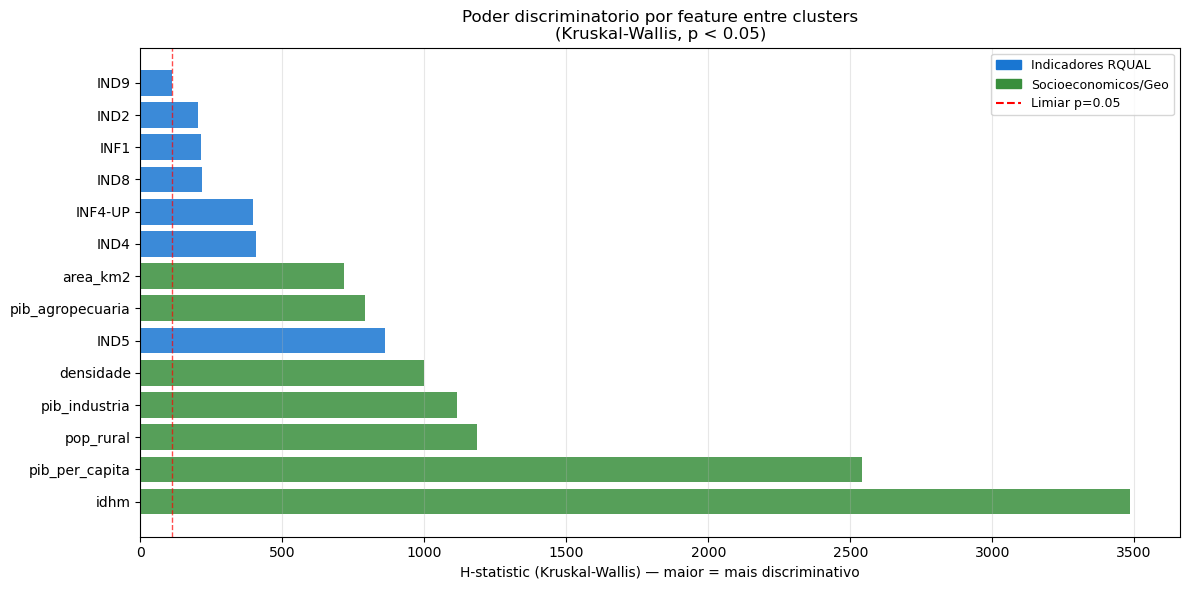

Salvo: fig_kruskal_wallis_discriminacao.png


In [10]:
# Bloco 9B — Validação estatística: ANOVA + Kruskal-Wallis por feature
from scipy import stats
import matplotlib.patches as mpatches

todas_feats = IND_COLS + SOC_COLS
resultados = []

for feat in todas_feats:
    grupos = [df.loc[df['kmeans_cluster'] == k, feat].dropna().values
              for k in sorted(df['kmeans_cluster'].unique())]
    grupos = [g for g in grupos if len(g) > 0]

    try:
        f_stat, p_anova = stats.f_oneway(*grupos)
    except Exception:
        f_stat, p_anova = float('nan'), float('nan')

    try:
        h_stat, p_kw = stats.kruskal(*grupos)
    except Exception:
        h_stat, p_kw = float('nan'), float('nan')

    resultados.append({
        'feature':    feat,
        'F':          round(f_stat, 1),
        'p_anova':    p_anova,
        'H':          round(h_stat, 1),
        'p_kw':       p_kw,
        'discrimina': 'Sim' if (p_kw is not None and p_kw < 0.05) else 'Nao',
    })

df_stat = pd.DataFrame(resultados).sort_values('H', ascending=False).reset_index(drop=True)
df_stat['p_anova_fmt'] = df_stat['p_anova'].apply(lambda p: f'{p:.2e}' if pd.notna(p) else '—')
df_stat['p_kw_fmt']    = df_stat['p_kw'].apply(lambda p: f'{p:.2e}' if pd.notna(p) else '—')

print('=' * 65)
print('VALIDACAO ESTATISTICA — Separacao dos clusters por feature')
print('=' * 65)
display(df_stat[['feature','F','p_anova_fmt','H','p_kw_fmt','discrimina']]
        .rename(columns={'p_anova_fmt':'p ANOVA','p_kw_fmt':'p Kruskal-Wallis'}))

n_discrimina = (df_stat['p_kw'] < 0.05).sum()
print(f'\n-> {n_discrimina}/{len(df_stat)} features discriminam significativamente (p < 0.05)')

# Gráfico: H-statistic por feature
CORES_FEATS = ['#1976D2' if f in IND_COLS else '#388E3C' for f in df_stat['feature']]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(df_stat['feature'], df_stat['H'], color=CORES_FEATS, alpha=0.85)

limiar_h = df_stat.loc[df_stat['p_kw'] < 0.05, 'H'].min()
ax.axvline(x=limiar_h, color='red', linestyle='--', linewidth=1,
           alpha=0.7, label=f'Limiar p=0.05 (H={limiar_h:.0f})')

patch_rqual = mpatches.Patch(color='#1976D2', label='Indicadores RQUAL')
patch_socio = mpatches.Patch(color='#388E3C', label='Socioeconomicos/Geo')
ax.legend(handles=[patch_rqual, patch_socio,
                   plt.Line2D([0],[0], color='red', linestyle='--', label=f'Limiar p=0.05')],
          fontsize=9)

ax.set_xlabel('H-statistic (Kruskal-Wallis) — maior = mais discriminativo')
ax.set_title('Poder discriminatorio por feature entre clusters\n(Kruskal-Wallis, p < 0.05)', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_kruskal_wallis_discriminacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_kruskal_wallis_discriminacao.png')


---

## 7. Análise HDBSCAN — Sub-estruturas dentro de cada cluster

O HDBSCAN foi aplicado dentro de cada macro-cluster K-Means para revelar **subestruturas de densidade local**: grupos de municípios que se destacam significativamente do padrão do seu próprio cluster — seja para melhor ou para pior.

> **Nota de leitura:** municípios classificados como *ruído* (noise) pelo HDBSCAN são aqueles sem vizinhança densa suficiente — representam casos intermediários ou isolados. Os *sub-clusters* são os casos onde há concentração real de perfis similares, distintos do restante do macro-cluster.

In [11]:
# Bloco 10 — Visão geral da distribuição HDBSCAN por macro-cluster

NOMES_CLUSTERS = {
    0: 'Urbano-Avançado',
    1: 'Intermediário',
    2: 'Nordeste-Periférico',
    3: 'Norte-Amazônico',
    4: 'Capitais-Destaques',
}

resumo_hdb = (
    df.groupby(['kmeans_cluster', 'hdbscan_cluster', 'hdbscan_noise'])
    .size()
    .reset_index(name='n')
    .sort_values(['kmeans_cluster', 'hdbscan_noise', 'n'], ascending=[True, True, False])
)

def hdb_label(row):
    if row['hdbscan_noise']:
        return 'ruído'
    return f'sub-cluster {row["hdbscan_cluster"]}'

resumo_hdb['grupo_hdbscan'] = resumo_hdb.apply(hdb_label, axis=1)
resumo_hdb['cluster_nome']  = resumo_hdb['kmeans_cluster'].map(NOMES_CLUSTERS)

print('Distribuição HDBSCAN por macro-cluster K-Means:')
display(
    resumo_hdb[['cluster_nome','grupo_hdbscan','n']]
    .rename(columns={'cluster_nome':'Cluster K-Means','grupo_hdbscan':'Grupo HDBSCAN','n':'Municípios'})
)

n_noise = df['hdbscan_noise'].sum()
n_sub   = (~df['hdbscan_noise']).sum()
print(f' Total em sub-clusters: {n_sub} municípios ({100*n_sub/len(df):.1f}%)')
print(f'Total ruído:           {n_noise} municípios ({100*n_noise/len(df):.1f}%)')

Distribuição HDBSCAN por macro-cluster K-Means:


,Cluster K-Means,Grupo HDBSCAN,Municípios
1,Urbano-Avançado,sub-cluster 0,50
2,Urbano-Avançado,sub-cluster 1,23
0,Urbano-Avançado,ruído,143
3,Intermediário,ruído,3054
4,Nordeste-Periférico,ruído,2057
6,Norte-Amazônico,sub-cluster 3000,112
7,Norte-Amazônico,sub-cluster 3001,19
5,Norte-Amazônico,ruído,85
8,Capitais-Destaques,ruído,27


 Total em sub-clusters: 204 municípios (3.7%)
Total ruído:           5366 municípios (96.3%)


### Achado 1 — C3 Norte/Amazônico: o sub-cluster do agronegócio mato-grossense

Dentro do pior cluster em qualidade (C3), o HDBSCAN identificou **19 municípios** que se comportam de forma radicalmente diferente dos seus vizinhos. São municípios de Mato Grosso (15), Mato Grosso do Sul (3) e Minas Gerais (1), classificados como "Norte/Amazônico" pelo K-Means pela combinação de grande área territorial, alta ruralidade e economia agropecuária — mas com indicadores de qualidade de telecom **muito superiores** ao restante do cluster.

In [12]:
# Bloco 11 — C3: comparação entre sub-clusters HDBSCAN

c3 = df[df['kmeans_cluster'] == 3].copy()

grupos_c3 = {
    'Ruído (85 mun.)':         c3[c3['hdbscan_cluster'] == -1],
    'Sub-cluster 3000 (112 mun. — Amazônia profunda)': c3[c3['hdbscan_cluster'] == 3000],
    'Sub-cluster 3001 (19 mun. — Agronegócio MT/MS)':  c3[c3['hdbscan_cluster'] == 3001],
}

# --- Tabela comparativa
perfil_c3 = pd.DataFrame({
    label: sub[IND_COLS].mean()
    for label, sub in grupos_c3.items()
}).T.round(3)

print('Perfil médio por grupo HDBSCAN — Cluster C3 (Norte/Amazônico):')
display(perfil_c3)

# --- Municípios do sub-cluster 3001
muns_3001 = c3[c3['hdbscan_cluster'] == 3001][['nome_mun_rqual','uf_rqual']].sort_values('uf_rqual')
print(f' Municípios do sub-cluster 3001 ({len(muns_3001)} municípios):')
display(muns_3001.reset_index(drop=True))

Perfil médio por grupo HDBSCAN — Cluster C3 (Norte/Amazônico):


,IND2,IND4,IND5,IND8,IND9,INF1,INF4-UP
Ruído (85 mun.),0.208,-1.772,-2.281,-1.231,-0.295,0.426,-0.197
Sub-cluster 3000 (112 mun. — Amazônia profunda),0.251,-1.808,-2.192,-0.309,0.138,0.301,-0.414
Sub-cluster 3001 (19 mun. — Agronegócio MT/MS),-0.519,-0.762,-0.593,-0.080,-0.314,0.074,-0.204


 Municípios do sub-cluster 3001 (19 municípios):


,nome_mun_rqual,uf_rqual
0,João Pinheiro,MG
1,Aquidauana,MS
2,Porto Murtinho,MS
3,Ribas do Rio Pardo,MS
4,Ribeirão Cascalheira,MT
5,Poconé,MT
6,Peixoto de Azevedo,MT
7,Vila Bela da Santíssima Trindade,MT
8,Juína,MT
9,Juara,MT


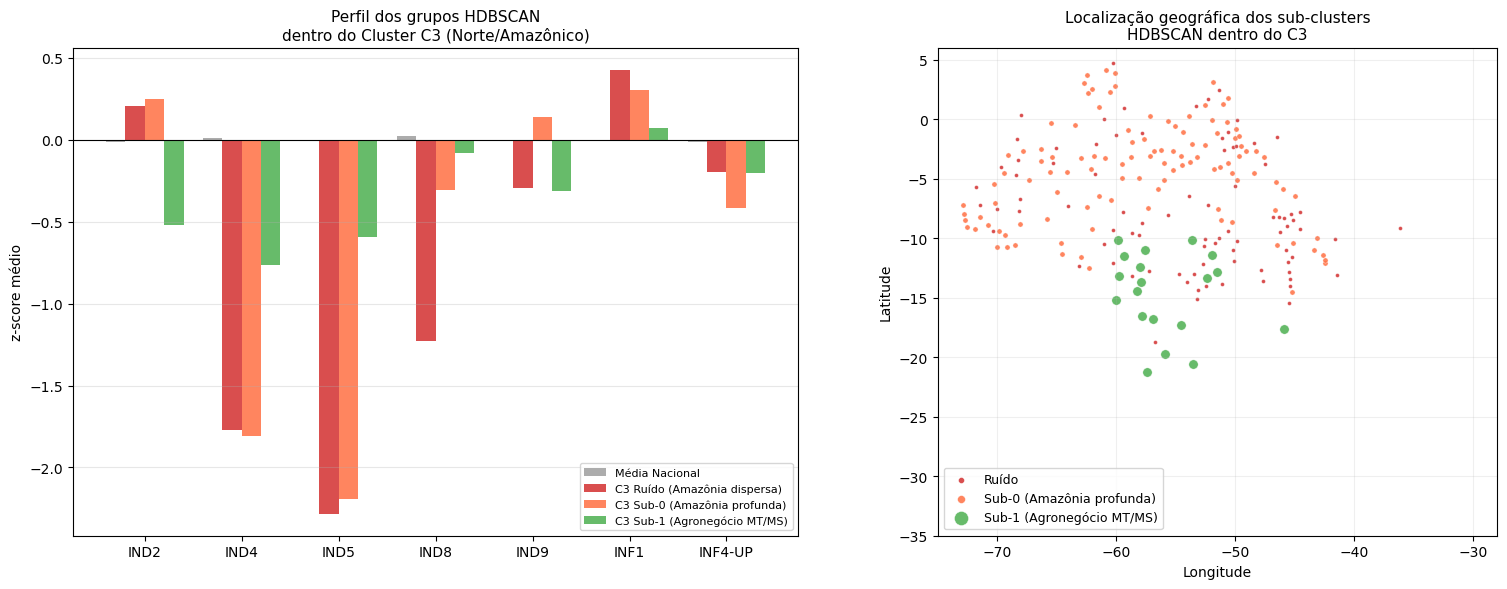

Salvo: fig_hdbscan_c3_subgrupos.png


In [13]:
# Bloco 12 — Gráfico comparativo C3: sub-clusters HDBSCAN vs média nacional

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Painel esquerdo: barras comparativas por indicador
grupos_plot = {
    'Média Nacional':                   df[IND_COLS].mean(),
    'C3 Ruído (Amazônia dispersa)':     c3[c3['hdbscan_cluster'] == -1][IND_COLS].mean(),
    'C3 Sub-0 (Amazônia profunda)':     c3[c3['hdbscan_cluster'] == 3000][IND_COLS].mean(),
    'C3 Sub-1 (Agronegócio MT/MS)':     c3[c3['hdbscan_cluster'] == 3001][IND_COLS].mean(),
}

cores_grupos = ['#9E9E9E', '#D32F2F', '#FF7043', '#4CAF50']
x = np.arange(len(IND_COLS))
width = 0.2

ax = axes[0]
for i, (label, vals) in enumerate(grupos_plot.items()):
    ax.bar(x + i*width, vals.values, width, label=label, color=cores_grupos[i], alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(IND_COLS, fontsize=10)
ax.set_ylabel('z-score médio')
ax.set_title('Perfil dos grupos HDBSCAN\ndentro do Cluster C3 (Norte/Amazônico)', fontsize=11)
ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='y', alpha=0.3)

# --- Painel direito: mapa usando coordenadas reais via geobr (evita conflito com lat/lon z-scored)
try:
    from geobr import read_municipality
    import warnings
    warnings.filterwarnings('ignore')

    gdf = read_municipality(code_muni='all', year=2020)
    gdf_proj = gdf.to_crs('EPSG:5880')
    gdf['lat_geo'] = gdf_proj.geometry.centroid.to_crs('EPSG:4326').y
    gdf['lon_geo'] = gdf_proj.geometry.centroid.to_crs('EPSG:4326').x
    gdf = gdf.rename(columns={'code_muni': 'cod_mun'})[['cod_mun', 'lat_geo', 'lon_geo']]
    gdf['cod_mun'] = gdf['cod_mun'].astype(int)

    # Merge usando sufixo para evitar conflito com lat/lon do pipeline (z-scored)
    c3_map = c3[['cod_mun', 'hdbscan_cluster']].merge(gdf, on='cod_mun', how='left')

    ax2 = axes[1]
    subgrupos_mapa = {
        'Ruído':                        (c3_map[c3_map['hdbscan_cluster'] == -1],    '#D32F2F', 8),
        'Sub-0 (Amazônia profunda)':    (c3_map[c3_map['hdbscan_cluster'] == 3000],  '#FF7043', 14),
        'Sub-1 (Agronegócio MT/MS)':    (c3_map[c3_map['hdbscan_cluster'] == 3001],  '#4CAF50', 45),
    }
    for label, (sub, cor, sz) in subgrupos_mapa.items():
        sub = sub.dropna(subset=['lat_geo', 'lon_geo'])
        ax2.scatter(sub['lon_geo'], sub['lat_geo'], c=cor, s=sz, alpha=0.85,
                    linewidths=0.3, edgecolors='white', label=label)

    ax2.set_xlim(-75, -28)
    ax2.set_ylim(-35, 6)
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.set_title('Localização geográfica dos sub-clusters\nHDBSCAN dentro do C3', fontsize=11)
    ax2.legend(fontsize=9, markerscale=1.5, loc='lower left')
    ax2.set_aspect('equal')
    ax2.grid(alpha=0.2)
except Exception as e:
    axes[1].text(0.5, 0.5, f'Mapa indisponível:\n{e}', ha='center', va='center',
                 transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('fig_hdbscan_c3_subgrupos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_hdbscan_c3_subgrupos.png')

### Achado 2 — C0 Urbano-Avançado: dois tipos de excelência

Dentro do melhor cluster (C0), o HDBSCAN separou dois grupos distintos de alta performance:

- **Sub-cluster 0 (50 mun.):** O topo absoluto — dominado por SP (28), os maiores valores de INF4-UP (+1,51σ) e IND9 (+0,68σ). Municípios onde o serviço é excelente em todas as dimensões.
- **Sub-cluster 1 (23 mun.):** Alta velocidade, mas **gargalo de atendimento** — IND4 = −0,37σ. SP (11) e RJ (6): metrópoles onde o volume de chamados supera a capacidade de atendimento das operadoras, apesar da qualidade técnica da rede.

Perfil médio por grupo HDBSCAN — Cluster C0 (Urbano-Avançado):


,IND2,IND4,IND5,IND8,IND9,INF1,INF4-UP
Ruído C0 (143 mun.),-0.490,-0.124,0.500,0.088,0.472,-0.460,1.129
Sub-cluster 0 (50 mun. — Elite total),-0.583,-0.115,0.624,0.359,0.679,-0.661,1.510
Sub-cluster 1 (23 mun. — Gargalo atend.),-0.496,-0.374,0.611,0.215,0.699,-0.688,1.362


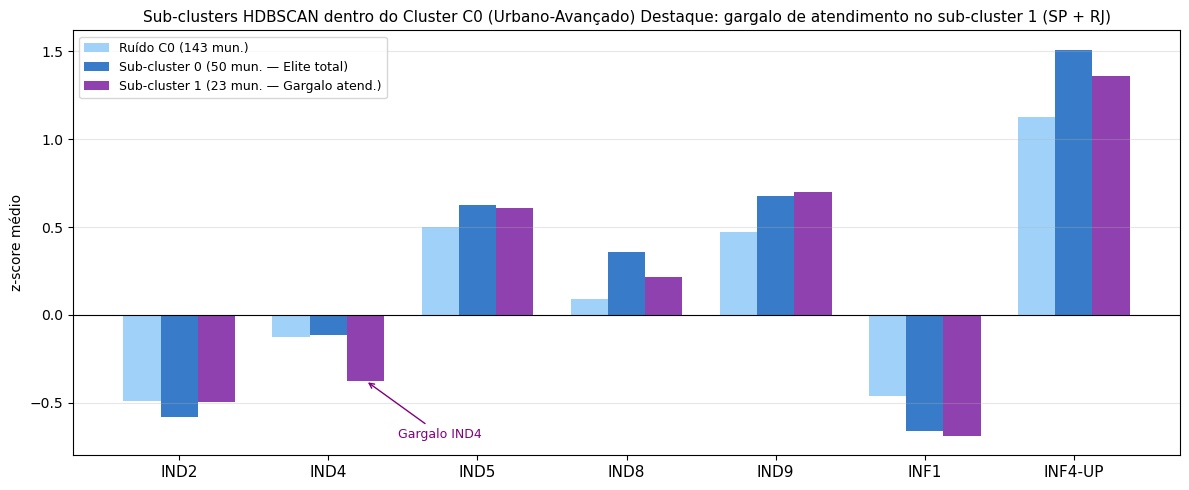

Salvo: fig_hdbscan_c0_subgrupos.png


In [14]:
# Bloco 13 — C0: comparação entre sub-clusters HDBSCAN

c0 = df[df['kmeans_cluster'] == 0].copy()

grupos_c0 = {
    'Ruído C0 (143 mun.)':              c0[c0['hdbscan_cluster'] == -1],
    'Sub-cluster 0 (50 mun. — Elite total)': c0[c0['hdbscan_cluster'] == 0],
    'Sub-cluster 1 (23 mun. — Gargalo atend.)': c0[c0['hdbscan_cluster'] == 1],
}

perfil_c0 = pd.DataFrame({
    label: sub[IND_COLS].mean()
    for label, sub in grupos_c0.items()
}).T.round(3)

print('Perfil médio por grupo HDBSCAN — Cluster C0 (Urbano-Avançado):')
display(perfil_c0)

fig, ax = plt.subplots(figsize=(12, 5))
cores_c0 = ['#90CAF9', '#1565C0', '#7B1FA2']
x = np.arange(len(IND_COLS))
width = 0.25

for i, (label, vals) in enumerate(
    {k: v[IND_COLS].mean() for k, v in grupos_c0.items()}.items()
):
    ax.bar(x + i*width, vals.values, width, label=label, color=cores_c0[i], alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(IND_COLS, fontsize=11)
ax.set_ylabel('z-score médio')
ax.set_title('Sub-clusters HDBSCAN dentro do Cluster C0 (Urbano-Avançado) Destaque: gargalo de atendimento no sub-cluster 1 (SP + RJ)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Anotação do gargalo
idx_ind4 = IND_COLS.index('IND4')
ax.annotate('Gargalo IND4', xy=(idx_ind4 + 2*width, -0.374),
            xytext=(idx_ind4 + 2*width + 0.5, -0.7),
            arrowprops=dict(arrowstyle='->', color='purple'),
            fontsize=9, color='purple', ha='center')

plt.tight_layout()
plt.savefig('fig_hdbscan_c0_subgrupos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_hdbscan_c0_subgrupos.png')

### Síntese dos achados HDBSCAN

| Sub-cluster | Municípios | Insight |
|-------------|-----------|--------|
| **C3 Sub-1** (3001) | 19 — MT/MS | Municípios remotos e rurais do agronegócio com qualidade **acima do esperado** para seu contexto geográfico. Exceção positiva dentro do pior cluster. |
| **C3 Sub-0** (3000) | 112 — PA/AM/AC/RR | Núcleo da Amazônia profunda: péssimo atendimento e prazo, mas velocidade de download acima da média (possivelmente satelital). |
| **C3 Ruído** | 85 — MT/AM/PA | Pior de todos: sem conectividade adequada nem qualidade operacional. |
| **C0 Sub-0** | 50 — SP/MG/RJ | Elite absoluta: melhor em todos os indicadores. Benchmark máximo nacional. |
| **C0 Sub-1** | 23 — SP/RJ | Alta qualidade técnica, mas gargalo de atendimento. Metrópoles com demanda superior à capacidade. |
| **C1, C2, C4** | — | Sem sub-estruturas densas: grupos homogêneos (C1), dispersos (C2) ou pequenos demais (C4). |

**Implicação regulatória-chave:** os 19 municípios do sub-cluster 3001 (MT/MS) demonstram que o contexto geográfico/rural **não é impeditivo** para boa qualidade. São evidência de que municípios do C3 Norte/Amazônico com investimento específico podem escapar do padrão crítico do cluster.

In [15]:
# Bloco 14 — Exportar tabela completa com labels HDBSCAN interpretados

label_hdbscan = {
    (-1,  True,  0): 'C0-ruído',
    ( 0,  False, 0): 'C0-elite-total',
    ( 1,  False, 0): 'C0-gargalo-atendimento',
    (-1,  True,  1): 'C1-intermediário',
    (-1,  True,  2): 'C2-nordeste-periférico',
    (-1,  True,  3): 'C3-norte-disperso',
    (3000,False, 3): 'C3-amazônia-profunda',
    (3001,False, 3): 'C3-agronegócio-MT',
    (-1,  True,  4): 'C4-capitais',
}

df['perfil_hdbscan'] = df.apply(
    lambda r: label_hdbscan.get(
        (r['hdbscan_cluster'], r['hdbscan_noise'], r['kmeans_cluster']),
        f'C{r["kmeans_cluster"]}-outro'
    ), axis=1
)

contagem = df['perfil_hdbscan'].value_counts().rename('n_municípios')
print('Distribuição final dos perfis HDBSCAN:')
display(contagem.reset_index().rename(columns={'index':'perfil'}))

df[['cod_mun','nome_mun_rqual','uf_rqual','kmeans_cluster','hdbscan_cluster','hdbscan_noise','perfil_hdbscan']
   + IND_COLS].to_csv('tabela_perfis_hdbscan.csv', index=False)
print(' Salvo: tabela_perfis_hdbscan.csv')

Distribuição final dos perfis HDBSCAN:


,perfil_hdbscan,n_municípios
0,C1-intermediário,3054
1,C2-nordeste-periférico,2057
2,C0-ruído,143
3,C3-amazônia-profunda,112
4,C3-norte-disperso,85
5,C0-elite-total,50
6,C4-capitais,27
7,C0-gargalo-atendimento,23
8,C3-agronegócio-MT,19


 Salvo: tabela_perfis_hdbscan.csv


## 6. Implicações para políticas públicas

Com base na segmentação, identificamos **três eixos prioritários de atuação regulatória**:

### Eixo 1 — Expansão de Qualidade (Cluster 3 — Norte/Amazônico)
- **Problema:** Municípios remotos com pior desempenho em atendimento e resolução
- **Ação:** Metas diferenciadas de SLA para prestadoras operando em municípios de alta extensão territorial
- **Indicadores-alvo:** IND4 (atendimento) e IND5 (resolução no prazo)

### Eixo 2 — Maturidade Operacional (Cluster 2 — Nordeste)
- **Problema:** Infraestrutura existe, mas qualidade operacional é inferior
- **Ação:** Programas de capacitação e monitoramento de SLA nas prestadoras regionais
- **Indicadores-alvo:** IND5 (resolução) e IND2 (reclamações)

### Eixo 3 — Manutenção e Benchmark (Clusters 0 e 4)
- **Papel:** Estabelecer padrões de referência para o restante do país
- **Ação:** Publicar benchmarks das melhores práticas e criar incentivos para replicação
- **Indicadores-alvo:** INF4-UP, IND8 (disponibilidade)

In [16]:
# Bloco 9 — Exportar tabela resumo como CSV

resumo = df.groupby('kmeans_cluster').agg(
    n_municipios=('cod_mun', 'count'),
    **{ind: (ind, 'mean') for ind in IND_COLS},
    **{soc: (soc, 'mean') for soc in SOC_COLS},
).round(3)

NOMES_CLUSTERS = {
    0: 'Urbano-Avançado',
    1: 'Intermediário',
    2: 'Nordeste-Periférico',
    3: 'Norte-Amazônico',
    4: 'Capitais-Destaques',
}
resumo.index = resumo.index.map(NOMES_CLUSTERS)
resumo.index.name = 'cluster'

resumo.to_csv('tabela_resumo_clusters.csv')
print('Salvo: tabela_resumo_clusters.csv')
display(resumo)

Salvo: tabela_resumo_clusters.csv


,n_municipios,IND2,IND4,IND5,IND8,IND9,INF1,INF4-UP,pib_agropecuaria,pib_industria,pib_per_capita,area_km2,densidade,pop_rural,idhm
cluster,,,,,,,,,,,,,,,
Urbano-Avançado,216,-0.512,-0.149,0.540,0.165,0.544,-0.531,1.242,-0.007,1.464,1.108,-0.150,1.400,0.019,1.264
Intermediário,3054,-0.045,0.185,0.285,0.129,0.010,-0.099,-0.037,0.042,-0.098,0.158,-0.135,-0.114,-0.344,0.593
Nordeste-Periférico,2057,0.069,-0.055,-0.264,-0.078,-0.069,0.176,-0.096,-0.242,-0.142,-0.440,-0.108,-0.109,0.331,-0.938
Norte-Amazônico,216,0.166,-1.702,-2.086,-0.652,-0.072,0.330,-0.310,0.789,-0.100,0.093,1.886,-0.189,1.124,-0.917
Capitais-Destaques,27,-0.680,0.140,0.283,0.069,0.360,-0.569,1.380,0.380,1.990,0.149,0.277,2.063,0.906,1.629
